In [4]:
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
oil = yf.download("BZ=F", start="2021-01-01", auto_adjust=True, progress=False)
oil.head()

Price,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,
2021-01-04,51.090000,53.320000,50.580002,51.660000,50232
2021-01-05,53.599998,53.880001,50.619999,50.740002,62791
2021-01-06,54.299999,54.720001,53.150002,53.590000,49186
2021-01-07,54.380001,54.900002,53.939999,54.139999,30800
2021-01-08,55.990002,56.299999,54.360001,54.459999,37597


In [5]:
tickers = {
    "Brent oil": "BZ=F",
    "US 10Y yield": "^TNX",
    "Emirates NBD": "EMIRATESNBD.AE",
    "Dubai Islamic Bank": "DIB.AE",
}

raw = yf.download(list(tickers.values()), start="2021-01-01",
                  auto_adjust=True, progress=False)["Close"]

raw = raw.rename(columns={code: name for name, code in tickers.items()})

print(raw.isna().sum())
raw.head()

Ticker
Brent oil              97
Dubai Islamic Bank    300
Emirates NBD          300
US 10Y yield          100
dtype: int64


Ticker,Brent oil,Dubai Islamic Bank,Emirates NBD,US 10Y yield
Date,,,,
2021-01-03,NaN,3.324415,8.118489,NaN
2021-01-04,51.090000,3.382483,8.466425,0.917
2021-01-05,53.599998,3.411517,8.505084,0.955
2021-01-06,54.299999,3.397001,8.427766,1.042
2021-01-07,54.380001,3.404259,8.505084,1.071


In [6]:
weekly = raw.ffill().resample("W-FRI").last()

rets = weekly.pct_change()
rets["US 10Y yield"] = weekly["US 10Y yield"].diff()
rets = rets.dropna()

print(len(rets), "weekly observations")
rets.head()

300 weekly observations


Ticker,Brent oil,Dubai Islamic Bank,Emirates NBD,US 10Y yield
Date,,,,
2021-01-15,-0.015896,0.059702,0.040909,-0.008
2021-01-22,0.005626,0.012072,0.013101,-0.006
2021-01-29,0.008482,0.001988,0.017241,0.002
2021-02-05,0.061918,-0.005952,-0.016949,0.077
2021-02-12,0.052073,-0.015968,0.004310,0.030


In [8]:
banks = ["Emirates NBD", "Dubai Islamic Bank"]

zeros = (rets[banks] == 0).sum()
print("Zero-change weeks:")
print(zeros)
print("Total weeks:", len(rets))

rets["Bank avg"] = rets[banks].mean(axis=1)

rets.corr().round(2)

Zero-change weeks:
Ticker
Emirates NBD          18
Dubai Islamic Bank    11
dtype: int64
Total weeks: 300


Ticker,Brent oil,Dubai Islamic Bank,Emirates NBD,US 10Y yield,Bank avg
Ticker,,,,,
Brent oil,1.00,-0.15,-0.12,0.23,-0.15
Dubai Islamic Bank,-0.15,1.00,0.50,-0.11,0.82
Emirates NBD,-0.12,0.50,1.00,-0.13,0.91
US 10Y yield,0.23,-0.11,-0.13,1.00,-0.14
Bank avg,-0.15,0.82,0.91,-0.14,1.00


In [9]:
# 1. How many weeks did each bank show exactly zero change?
zeros = (rets[["Emirates NBD", "Mashreq"]] == 0).sum()
print("Zero-change weeks:")
print(zeros)
print("Total weeks:", len(rets))
print((zeros / len(rets) * 100).round(0), "% of weeks")

# 2. Average of the two banks
rets["Bank avg"] = rets[["Emirates NBD", "Mashreq"]].mean(axis=1)

# 3. Correlation table
rets.corr().round(2)

Zero-change weeks:
Ticker
Emirates NBD    18
Mashreq         81
dtype: int64
Total weeks: 300
Ticker
Emirates NBD     6.0
Mashreq         27.0
dtype: float64 % of weeks


Ticker,Brent oil,Emirates NBD,Mashreq,US 10Y yield,Bank avg
Ticker,,,,,
Brent oil,1.00,-0.12,-0.09,0.23,-0.13
Emirates NBD,-0.12,1.00,0.12,-0.14,0.68
Mashreq,-0.09,0.12,1.00,0.04,0.80
US 10Y yield,0.23,-0.14,0.04,1.00,-0.05
Bank avg,-0.13,0.68,0.80,-0.05,1.00


In [10]:
candidates = ["FAB.AE", "DIB.AE", "ADCB.AE", "FAB.AD", "ADCB.AD", "DIB.DU"]

for c in candidates:
    try:
        d = yf.download(c, start="2021-01-01", auto_adjust=True, progress=False)["Close"].squeeze()
        d = d.dropna()
        if len(d) == 0:
            print(c, "| no data")
            continue
        w = d.resample("W-FRI").last().pct_change().dropna()
        print(c, "| start:", d.index[0].date(), "| weeks:", len(w),
              "| zero-change weeks: {:.0f}%".format((w == 0).mean() * 100))
    except Exception:
        print(c, "| failed")

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FAB.AE"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FAB.AE']: YFTzMissingError('possibly delisted; no timezone found')


FAB.AE | no data


/tmp/ipykernel_2297/3520621811.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  w = d.resample("W-FRI").last().pct_change().dropna()


DIB.AE | start: 2021-01-03 | weeks: 300 | zero-change weeks: 4%


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ADCB.AE"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ADCB.AE']: YFTzMissingError('possibly delisted; no timezone found')


...

FAB.AD | no data


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ADCB.AD']: YFTzMissingError('possibly delisted; no timezone found')


ADCB.AD | no data


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DIB.DU']: YFTzMissingError('possibly delisted; no timezone found')


DIB.DU | no data


In [9]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = {
    "Brent oil": "BZ=F",
    "US 10Y yield": "^TNX",
    "Emirates NBD": "EMIRATESNBD.AE",
    "Dubai Islamic Bank": "DIB.AE",
}

raw = yf.download(list(tickers.values()), start="2021-01-01",
                  auto_adjust=True, progress=False)["Close"]
raw = raw.rename(columns={code: name for name, code in tickers.items()})

weekly = raw.ffill().resample("W-FRI").last()
rets = weekly.pct_change(fill_method=None)
rets["US 10Y yield"] = weekly["US 10Y yield"].diff()
rets = rets.dropna()

banks = ["Emirates NBD", "Dubai Islamic Bank"]
print("Columns:", list(rets.columns))
print("Total weeks:", len(rets))
print("Zero-change weeks:")
print((rets[banks] == 0).sum())

rets["Bank avg"] = rets[banks].mean(axis=1)
rets.corr().round(2)

Columns: ['Brent oil', 'Dubai Islamic Bank', 'Emirates NBD', 'US 10Y yield']
Total weeks: 300
Zero-change weeks:
Ticker
Emirates NBD          18
Dubai Islamic Bank    11
dtype: int64


Ticker,Brent oil,Dubai Islamic Bank,Emirates NBD,US 10Y yield,Bank avg
Ticker,,,,,
Brent oil,1.00,-0.15,-0.12,0.23,-0.15
Dubai Islamic Bank,-0.15,1.00,0.50,-0.11,0.82
Emirates NBD,-0.12,0.50,1.00,-0.13,0.91
US 10Y yield,0.23,-0.11,-0.13,1.00,-0.14
Bank avg,-0.15,0.82,0.91,-0.14,1.00


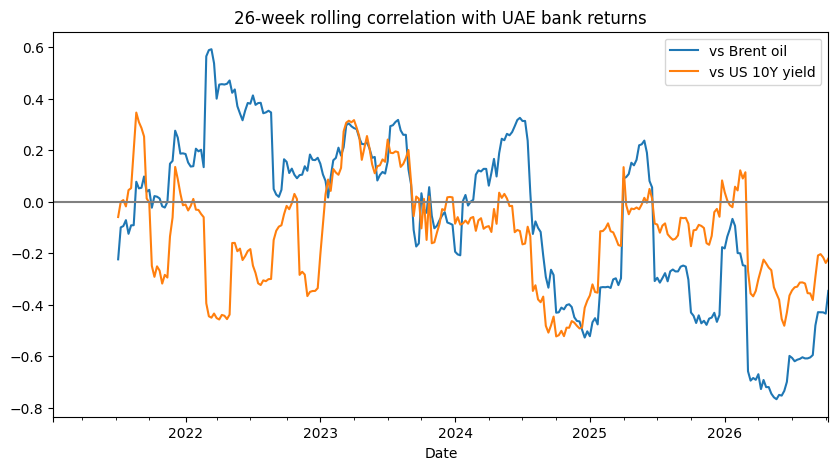

2021-2022 | weeks: 103
Ticker
Brent oil       0.23
US 10Y yield   -0.19
Name: Bank avg, dtype: float64
2023-now | weeks: 197
Ticker
Brent oil      -0.33
US 10Y yield   -0.12
Name: Bank avg, dtype: float64


In [10]:
# Rolling 26-week correlation of bank returns with oil and rates
roll = pd.DataFrame({
    "vs Brent oil": rets["Bank avg"].rolling(26).corr(rets["Brent oil"]),
    "vs US 10Y yield": rets["Bank avg"].rolling(26).corr(rets["US 10Y yield"]),
})
ax = roll.plot(figsize=(10, 5), title="26-week rolling correlation with UAE bank returns")
ax.axhline(0, color="grey")
plt.savefig("rolling_corr.png", dpi=150, bbox_inches="tight")
plt.show()

# Two sub-periods
for name, part in {"2021-2022": rets[:"2022-12-31"],
                   "2023-now": rets["2023-01-01":]}.items():
    print(name, "| weeks:", len(part))
    print(part.corr()["Bank avg"][["Brent oil", "US 10Y yield"]].round(2))

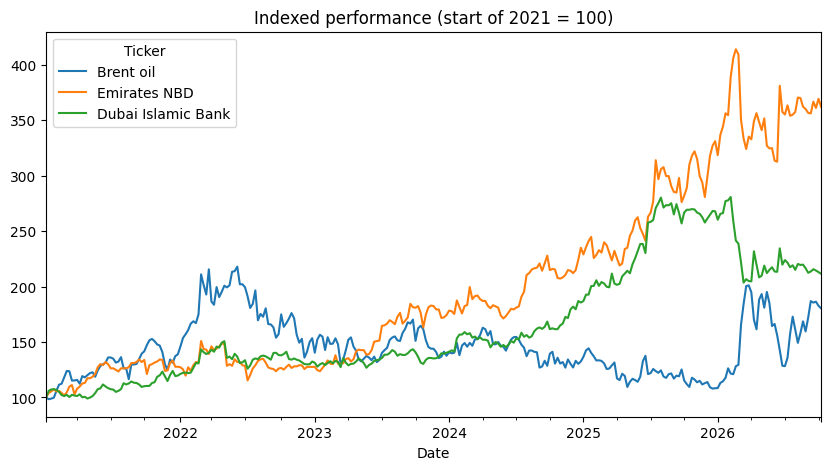

In [11]:
idx = weekly[["Brent oil", "Emirates NBD", "Dubai Islamic Bank"]]
(idx / idx.iloc[0] * 100).plot(figsize=(10, 5),
    title="Indexed performance (start of 2021 = 100)")
plt.savefig("indexed.png", dpi=150, bbox_inches="tight")
plt.show()

rets.corr().round(2).to_csv("correlations.csv")

In [12]:
rets[["Dubai Islamic Bank", "Emirates NBD"]].sort_values("Dubai Islamic Bank").head(5)

Ticker,Dubai Islamic Bank,Emirates NBD
Date,,
2022-05-13,-0.100000,-0.134426
2026-03-13,-0.082279,-0.048658
2026-02-13,-0.077000,0.044118
2026-03-06,-0.070588,-0.143678
2026-02-20,-0.068256,0.019718


In [13]:
print("Rank-based (Spearman) correlation with Bank avg:")
print(rets.corr(method="spearman")["Bank avg"][["Brent oil", "US 10Y yield"]].round(2))

Rank-based (Spearman) correlation with Bank avg:
Ticker
Brent oil      -0.09
US 10Y yield   -0.11
Name: Bank avg, dtype: float64


In [14]:
for name, part in {"2021-2022": rets[:"2022-12-31"],
                   "2023-now": rets["2023-01-01":]}.items():
    print(name, "| weeks:", len(part))
    print(part.corr(method="spearman")["Bank avg"][["Brent oil", "US 10Y yield"]].round(2))

2021-2022 | weeks: 103
Ticker
Brent oil       0.05
US 10Y yield   -0.20
Name: Bank avg, dtype: float64
2023-now | weeks: 197
Ticker
Brent oil      -0.16
US 10Y yield   -0.06
Name: Bank avg, dtype: float64
